In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
folder = Path("/mnt/c/users/helen/Desktop/U2OS")

In [18]:
dfs = []

for file in folder.glob("*.csv"):

    df = pd.read_csv(file)

    # Add file name column
    df["file_name"] = file.stem

    dfs.append(df)

# Combine all dataframes
data = pd.concat(dfs, ignore_index=True)

# Column ordering
data = data[
    ["file_name", "ROI", "Area", "Mean"]
]

# Rename ROI column to remove the suffix after the underscore
data["ROI"] = data["ROI"].apply(lambda x: x.split("_")[0])

In [19]:
data

,file_name,ROI,Area,Mean
0,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Nucleus,283.320,2.998
1,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Whole,1186.204,0.821
2,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Cytoplasm,903.206,0.138
3,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Nucleus,249.577,27.742
4,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Whole,545.672,15.616
5,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Cytoplasm,296.095,5.396
6,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_03...,Nucleus,281.867,6.637
7,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_03...,Whole,771.183,3.048
8,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_03...,Cytoplasm,489.316,0.981
9,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_04...,Nucleus,231.836,4.540


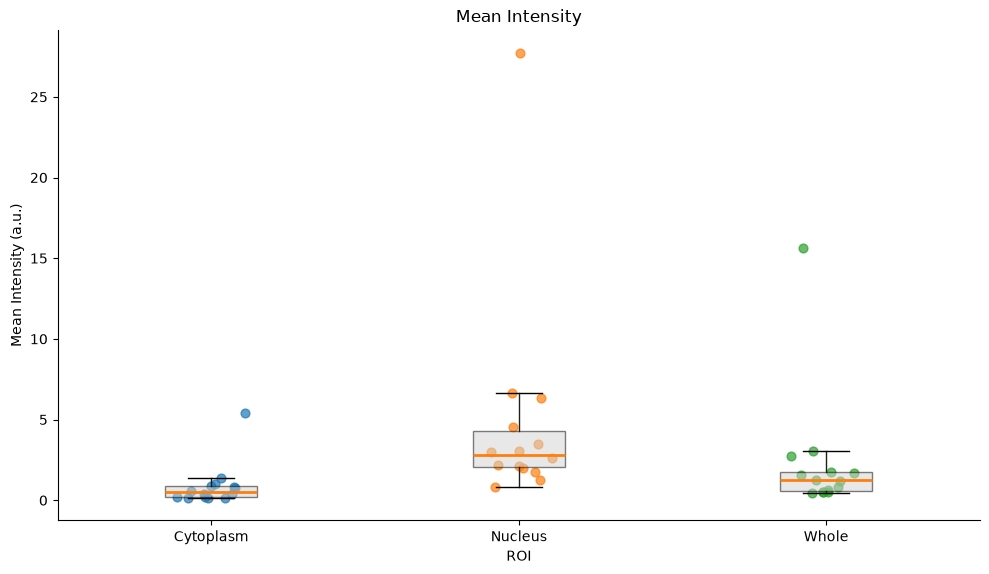

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot
data.boxplot(
    column="Mean",
    by="ROI",
    ax=ax,
    grid=False,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray", alpha=0.5),
    medianprops=dict(linewidth=2),
)

# Add individual points (jitter)
groups = data.groupby("ROI")

for i, (_, group) in enumerate(groups, start=1):
    x = np.random.normal(i, 0.06, size=len(group))
    ax.scatter(
        x,
        group["Mean"],
        alpha=0.7,
        s=40,
    )

ax.set_title("Mean Intensity")
ax.set_xlabel("ROI")
ax.set_ylabel("Mean Intensity (a.u.)")

# Remove Pandas automatic title
plt.suptitle("")

# Cleaner appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()